In [1]:
import QuantLib as ql

In [2]:
today = ql.Date(7, ql.March, 2014)
ql.Settings.instance().evaluationDate = today

<h3>The Instrument</h3>

As a sample instrument, we’ll take a textbook example: a European option.

In [3]:
option = ql.EuropeanOption(ql.PlainVanillaPayoff(ql.Option.Call, 100.0),
                           ql.EuropeanExercise(ql.Date(7, ql.June, 2014)))

<b>First pricing method: analytic Black-Scholes formula</b>

In [4]:
u = ql.SimpleQuote(100.0)
r = ql.SimpleQuote(0.01)
sigma = ql.SimpleQuote(.20)

Black Scholles process need flat curves for risk-free rate and volatility

In [5]:
riskFreeCurve = ql.FlatForward(0, ql.TARGET(),
                              ql.QuoteHandle(r), ql.Actual360())
volatility = ql.BlackConstantVol(0, ql.TARGET(),
                                ql.QuoteHandle(sigma), ql.Actual360())

then we instantiate the process with the underlying value and the curves we just built.

In [6]:
process = ql.BlackScholesProcess(ql.QuoteHandle(u),
                                 ql.YieldTermStructureHandle(riskFreeCurve),
                                 ql.BlackVolTermStructureHandle(volatility))

Once we have the process, we can finally use it to build the engine…

In [7]:
engine = ql.AnalyticEuropeanEngine(process)

…and once we have the engine, we can set it to the option and evaluate the latter.

In [8]:
option.setPricingEngine(engine)

In [9]:
print(option.NPV())

4.155543462156206


Depending on the instrument and the engine, we can also ask for other results; in this case, we can
ask for Greeks.

In [10]:
print(option.delta())
print(option.gamma())
print(option.vega())

0.5302223303784392
0.03934493301271913
20.109632428723106


<h4>Market Changes</h4>

In [11]:
u.setValue(105.0)
print(option.NPV())

7.27556357927846


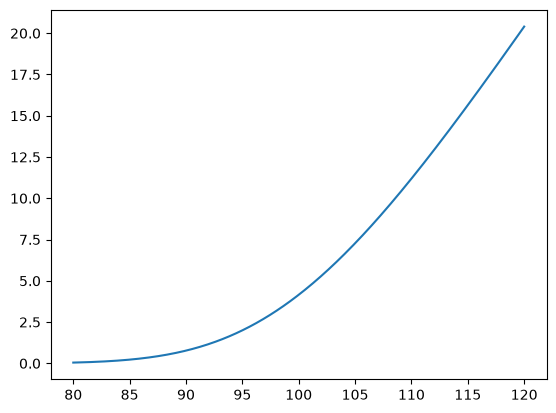

In [12]:
import matplotlib.pyplot as plt
import numpy as np

xs = np.linspace(80.0, 120.0, 400)
x= []
y=[]
for i in xs:
    u.setValue(i)
    x.append(i)
    y.append(option.NPV())
    
plt.plot(x,y)
plt.show()

Other market data also affect the value, of course.

In [13]:
u.setValue(105.0)
r.setValue(0.01)
sigma.setValue(0.20)

In [14]:
print(option.NPV())

7.27556357927846


We can see it when we change the risk-free rate…

In [15]:
r.setValue(0.03)

In [16]:
print(option.NPV())

7.624029148527754


…or the volatility.

In [17]:
sigma.setValue(0.25)

In [18]:
print(option.NPV())

8.531296969971573


<h4>Date changes</h4>

Just as it does when inputs are modified, the value also changes if we advance the evaluation date.

In [19]:
ql.Settings.instance().evaluationDate=ql.Date(7, ql.April, 2014)

In [20]:
print(option.NPV())

7.510886570407359


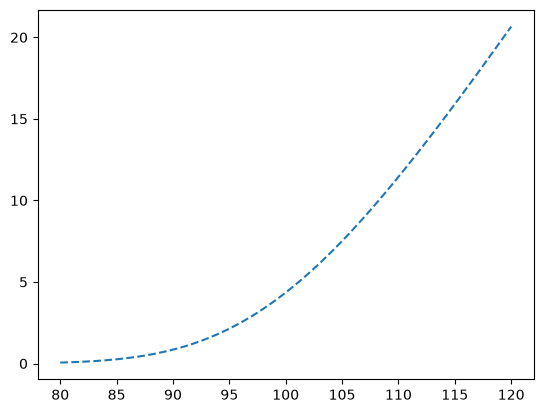

In [21]:
import matplotlib.pyplot as plt
import numpy as np

xs = np.linspace(80.0, 120.0, 400)
x= []
y=[]
for i in xs:
    u.setValue(i)
    x.append(i)
    y.append(option.NPV())
    
plt.plot(x,y,'--')
plt.show()

In the default library configuration, the returned value goes down to 0 when we reach the exercise
date.

In [22]:
ql.Settings.instance().evaluationDate= ql.Date(7, ql.June, 2014)

In [23]:
print(option.NPV())

0.0


<h4>Other pricing methods</h4>

<b>Heston Pricing Model</b>

In [24]:
today = ql.Date(7, ql.March, 2014)
ql.Settings.instance().evaluationDate=today

In [25]:
option = ql.EuropeanOption(ql.PlainVanillaPayoff(ql.Option.Call, 100.0),
                          ql.EuropeanExercise(ql.Date(7, ql.June, 2014)))

In [26]:
u.setValue(105.0)
r.setValue(0.01)
sigma.setValue(0.20)

In [27]:
model = ql.HestonModel(
    ql.HestonProcess(
        ql.YieldTermStructureHandle(riskFreeCurve),
        ql.YieldTermStructureHandle(ql.FlatForward(0, ql.TARGET(),
                                    0.0, ql.Actual360())),
        ql.QuoteHandle(u),
        0.04, 0.1, 0.01, 0.05, -0.75
    )
)

…pass it to the corresponding engine, and set the new engine to the option.

In [28]:
engine = ql.AnalyticHestonEngine(model)
option.setPricingEngine(engine)

In [29]:
print(option.NPV())

7.295356086978634


<h4>Lazy recalculation</h4>

We’ll switch to a Monte Carlo engine, which takes a few seconds to run the required simulation.

In [30]:
engine = ql.MCEuropeanEngine(process,"PseudoRandom",
                            timeSteps = 20,
                            requiredSamples = 250000)
option.setPricingEngine(engine)

In [31]:
%time print(option.NPV())

7.284840235924032
CPU times: user 1.35 s, sys: 0 ns, total: 1.35 s
Wall time: 1.36 s


In [32]:
%time print(option.NPV())

7.284840235924032
CPU times: user 210 μs, sys: 0 ns, total: 210 μs
Wall time: 180 μs


In [33]:
%time print(option.NPV())

7.284840235924032
CPU times: user 167 μs, sys: 0 ns, total: 167 μs
Wall time: 162 μs


If we change anything (e.g., the underlying value)…he option is notified of the change, and the next call to NPV will again take a while.

In [34]:
u.setValue(104.0)

In [35]:
%time print(option.NPV())

6.579222128388253
CPU times: user 1.27 s, sys: 3.13 ms, total: 1.28 s
Wall time: 1.28 s
